In [300]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import holidays

## Loading & Checking the Data

Source: https://www.entsoe.eu/data/power-stats/

Years: 2019-2025

In [52]:
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

In [204]:
dfs = []

In [205]:
for year in years:
    if year in [2021, 2022]:
        loaded = pd.read_csv(f'.\data\{year}.csv', sep=";")
    else:
        loaded = pd.read_csv(f'.\data\{year}.csv', sep="\t")
    loaded_at = loaded[loaded["CountryCode"] == "AT"].copy()
    loaded_at["DateUTC"] = pd.to_datetime(loaded_at["DateUTC"], dayfirst = True)
    loaded_at = loaded_at.sort_values("DateUTC")
    dfs.append(loaded_at[["DateUTC", "Value"]])
    

In [225]:
len(dfs)

7

In [222]:
data = pd.concat(dfs)
data = data.sort_values("DateUTC")
data = data.set_index("DateUTC")
data = data.groupby(data.index).mean() #Removes Duplicate Entries on Summertime change

In [223]:
data.isna().sum()

Value    0
dtype: int64

In [224]:
data.head()

,Value
DateUTC,
2019-01-01 00:00:00,5852.5
2019-01-01 01:00:00,5619.2
2019-01-01 02:00:00,5323.9
2019-01-01 03:00:00,5273.3
2019-01-01 04:00:00,5439.0


In [226]:
print(data.index.min())
print(data.index.max())
print(len(data))
print(data.index.inferred_freq)

2019-01-01 00:00:00
2025-09-30 23:00:00
59154
None


In [228]:
data = data.asfreq("h")

In [230]:
print(data.index.inferred_freq)

h


In [229]:
data.isna().sum()

Value    6
dtype: int64

In [231]:
data.index.duplicated().sum()

np.int64(0)

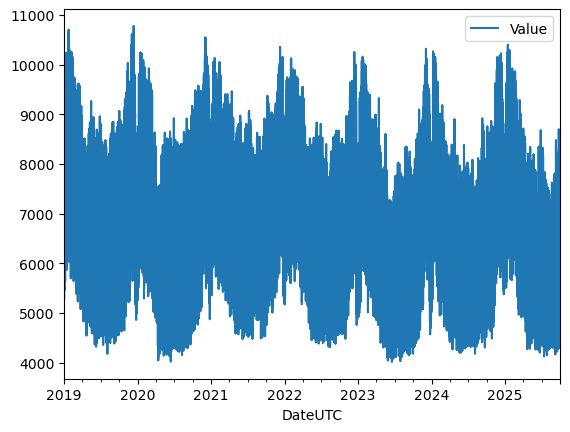

In [238]:
data.plot()
plt.show()

## Creating Features

In [262]:
data["weekday"] = data.index.day_name()
data["day"] = data.index.day
data["hour"] = data.index.hour
data["month"] = data.index.month

In [280]:
data["lag_1"] = data["Value"].shift(1)
data["lag_24"] = data["Value"].shift(24)
data["lag_168"] = data["Value"].shift(168)

In [291]:
data["rolling_mean_24"] = data["Value"].shift(1).rolling(window = 24).mean()
data["rolling_std_24"] = data["Value"].shift(1).rolling(window = 24).std()
data["rolling_mean_168"] = data["Value"].shift(1).rolling(window = 168).mean()
data["rolling_std_168"] = data["Value"].shift(1).rolling(window = 168).std()

In [301]:
holidays = holidays.Austria(years = years)

In [335]:
list(holidays.keys())[0]

datetime.date(2019, 1, 1)

In [336]:
type(list(holidays.keys())[0])

datetime.date

In [319]:
data["is_weekend"] = data["weekday"].isin(["Saturday", "Sunday"])

In [342]:
data["is_holiday"] = data.index.date.isin(holidays.keys())

AttributeError: 'numpy.ndarray' object has no attribute 'isin'

In [328]:
data[data["is_holiday"]==True].tail()

,Value,weekday,hour,month,day,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,day_is_weekend,is_weekend,is_holiday
DateUTC,,,,,,,,,,,,,,,
2025-08-15 19:00:00,5846.1,Friday,19,8,15,6069.1,6601.1,6274.2,5257.983333,572.719265,5735.163095,860.609203,False,False,True
2025-08-15 20:00:00,5696.7,Friday,20,8,15,5846.1,6256.2,5987.4,5226.525000,513.400301,5732.614881,859.636828,False,False,True
2025-08-15 21:00:00,5406.0,Friday,21,8,15,5696.7,5757.1,5575.6,5203.212500,475.948827,5730.884524,859.413447,False,False,True
2025-08-15 22:00:00,5281.0,Friday,22,8,15,5406.0,5174.0,5090.1,5188.583333,463.414674,5729.875000,859.696512,False,False,True
2025-08-15 23:00:00,4985.7,Friday,23,8,15,5281.0,4899.7,4788.8,5193.041667,463.782830,5731.011310,858.971678,False,False,True


In [307]:
for date, is_holiday in zip(data.index, data[[holiday"]]):
    if not is_holiday:
        if date in holidays.keys():
            data[date].is_holiday = True


SyntaxError: unterminated string literal (detected at line 1) (1840553703.py, line 1)

In [299]:
data[0:2]

,Value,weekday,hour,month,day,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,day_is_weekend,is_weekend
DateUTC,,,,,,,,,,,,,,
2019-01-01 00:00:00,5852.5,Tuesday,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2019-01-01 01:00:00,5619.2,Tuesday,1,1,1,5852.5,NaN,NaN,NaN,NaN,NaN,NaN,False,False


In [293]:
data[24:26]

,Value,weekday,hour,month,day,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168
DateUTC,,,,,,,,,,,,
2019-01-02 00:00:00,5665.2,Wednesday,0,1,2,5927.9,5852.5,NaN,6489.000000,733.306398,NaN,NaN
2019-01-02 01:00:00,5546.1,Wednesday,1,1,2,5665.2,5619.2,NaN,6481.195833,741.327621,NaN,NaN


In [290]:
data[168:170]

,Value,weekday,hour,month,day,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
DateUTC,,,,,,,,,,
2019-01-08 00:00:00,6868.8,Tuesday,0,1,8,7071.8,6089.6,5852.5,8526.266667,1493.721086
2019-01-08 01:00:00,6744.7,Tuesday,1,1,8,6868.8,5961.5,5619.2,8558.733333,1446.167574
